Prime righe del dataset:
              Nome film  Action  Adventure  Animation  Comedy  Crime  Drama  \
0              Ne Zha 2       1        1.0        1.0     1.0    NaN    1.0   
1            Zootopia 2       1        1.0        1.0     1.0    1.0    NaN   
2  Avatar: Fire and Ash       1        1.0        1.0     NaN    NaN    NaN   
3         Lilo & Stitch       1        1.0        NaN     1.0    NaN    1.0   
4     A Minecraft Movie       1        1.0        NaN     1.0    NaN    NaN   

   Family  Fantasy  Mystery  Sci-Fi  Thriller  Sport  
0     NaN      1.0      NaN     NaN       NaN    NaN  
1     1.0      NaN      1.0     NaN       NaN    NaN  
2     NaN      1.0      NaN     1.0       NaN    NaN  
3     1.0      1.0      NaN     1.0       NaN    NaN  
4     1.0      1.0      NaN     NaN       NaN    NaN  




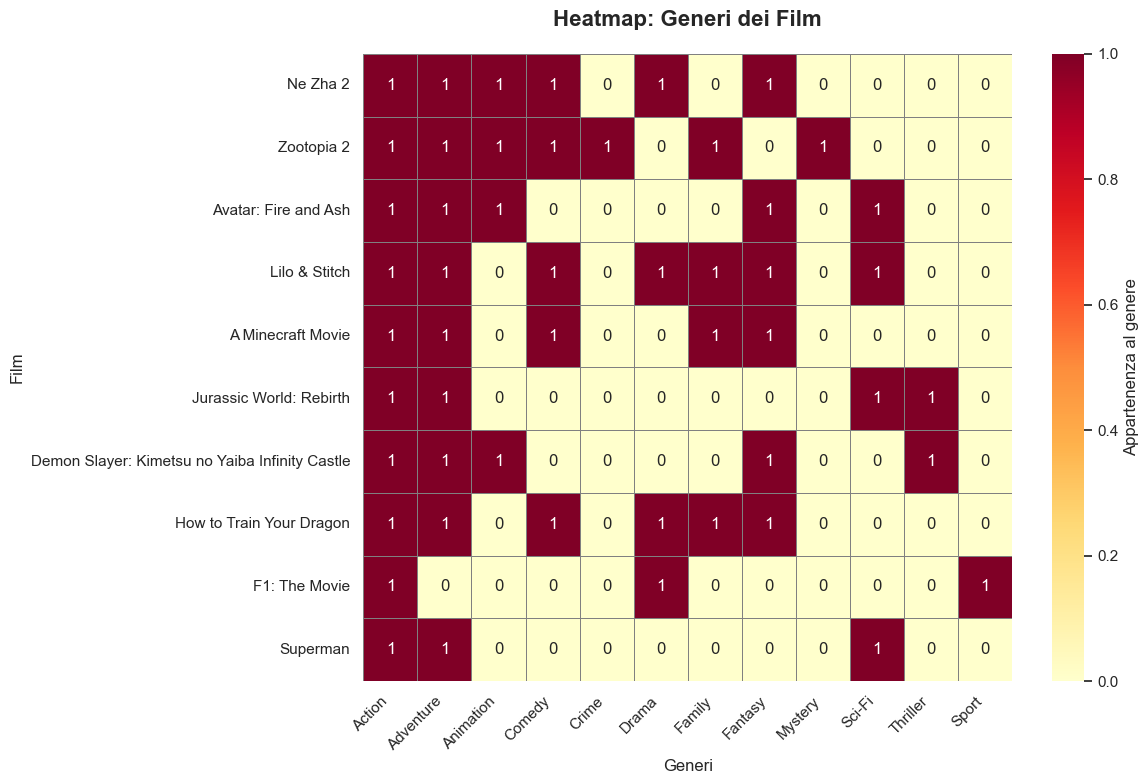

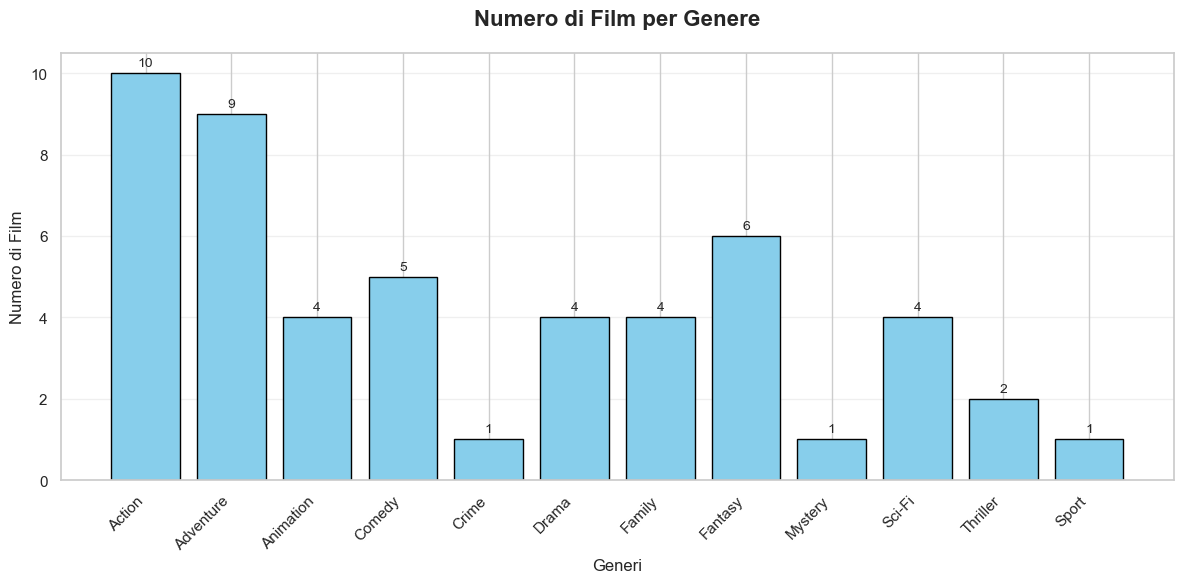

Sommario statistiche:
------------------------------
Numero totale di film: 10
Numero totale di generi: 12

Film per genere:
Action: 10 film
Adventure: 9 film
Animation: 4 film
Comedy: 5 film
Crime: 1 film
Drama: 4 film
Family: 4 film
Fantasy: 6 film
Mystery: 1 film
Sci-Fi: 4 film
Thriller: 2 film
Sport: 1 film

Genere più comune: Action (10 film)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imposta lo stile dei grafici
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Carica i dati
df = pd.read_csv('Genere film - Foglio1.csv')

# Visualizza le prime righe per controllo
print("Prime righe del dataset:")
print(df.head())
print("\n" + "="*60 + "\n")

# Prepara i dati per la heatmap
# Imposta il nome del film come indice
df_heatmap = df.set_index('Nome film')

# Sostituisce i valori vuoti con 0
df_heatmap = df_heatmap.replace('', 0).fillna(0)

# Converti tutti i valori in numerici
df_heatmap = df_heatmap.astype(float)

# Crea la heatmap
plt.figure(figsize=(12, 8))
heatmap = sns.heatmap(df_heatmap, 
                      annot=True, 
                      cmap='YlOrRd', 
                      cbar_kws={'label': 'Appartenenza al genere'},
                      linewidths=0.5,
                      linecolor='gray')

plt.title('Heatmap: Generi dei Film', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Generi', fontsize=12)
plt.ylabel('Film', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")

# Creazione dell'istogramma dei generi
# Calcola la somma dei film per ogni genere
genre_counts = df_heatmap.sum()

# Crea l'istogramma
plt.figure(figsize=(12, 6))
bars = plt.bar(genre_counts.index, genre_counts.values, color='skyblue', edgecolor='black')

# Aggiungi i valori sulle barre
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.title('Numero di Film per Genere', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Generi', fontsize=12)
plt.ylabel('Numero di Film', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Informazioni aggiuntive
print("Sommario statistiche:")
print("-" * 30)
print(f"Numero totale di film: {len(df)}")
print(f"Numero totale di generi: {len(genre_counts)}")
print("\nFilm per genere:")
for genre, count in genre_counts.items():
    print(f"{genre}: {int(count)} film")

# Trova il genere più comune
most_common_genre = genre_counts.idxmax()
most_common_count = genre_counts.max()
print(f"\nGenere più comune: {most_common_genre} ({int(most_common_count)} film)")